<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Tutorial A.3: Searches for continuous gravitational waves with the frequency-Hough Transform

Searching for continuous gravitational waves from isolated, asymmetricly rotating neutron stars


Searches for continuous waves from isolated, deformed neutron stars are broadly classified into three forms, depending on how much we know about the source: targeted (known position, rotational frequency and spin-down), directed (known position, unknown frequency/spin-down) and all-sky (all parameters unknown).

There are benefits and drawbacks to each kind of search -- see arXiv:2206.06447 for a recent review.

This tutorial will focus on a particular algorithm for all-sky searches for continuous gravitational waves: the frequency-Hough transform. This method maps points in the time/frequency plane of the detector to lines in the frequency/spin-down plane of the source. See arXiv:1407.8333 for more details.

Note: The frequency-Hough transform algorithm and its implementation for CW searches has been designed and implemented for real searches by the Virgo Rome group of the LVK collaboration

In [2]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [3]:
!pip install -q pyhough==0.0.10 datasets==3.6.0

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.9 MB/s eta 0:00:00


# Import stuff

In [4]:
import os
import pyfstat
import numpy as np
import pyhough
# For some reason pm and hm need to be imported separately from pyhough
from pyhough import pm
from pyhough import hm
# Make sure to import matplotlib after the pyfstat
# Also, the %matplotlib inline magic is needed here
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib.pyplot as plt
%matplotlib inline


# Simulate a CW signal and compute a spectrogram

Compute the spectrogram of a set of SFTs. This is useful to produce
visualizations of the Doppler modulation of a CW signal.


In [5]:
# general setup
label = "PyFstatExampleSpectrogram"
outdir = os.path.join("./tuto_A.3/PyFstat_example_data", label)
logger = pyfstat.set_up_logger(label=label, outdir=outdir)

In [6]:
# properties of the GW data
depth = 5 ## this is a measure of strength of the GW signal. Larger depth --> smaller GW amplitude

data_parameters = {
    "sqrtSX": 1e-23,
    "tstart": 1000000000,
    "duration": 0.4 * 365 * 86400,
    "detectors": "H1",
    "Tsft": 1800,
}

signal_parameters = {
    "F0": 100.0,
    "F1": -1e-9,
    "F2": 0,
    "Alpha": np.pi/2,
    "Delta": 0.0,
#     "tp": 0,#data_parameters["tstart"],
#     "asini": 0,#25.0,
#     "period": 0,#50 * 86400,
    "tref": data_parameters["tstart"],
    "h0": data_parameters["sqrtSX"] / depth,
    "cosi": 1.0,
}

In [7]:
# making data
data = pyfstat.Writer(
    label=label, outdir=outdir, **data_parameters, **signal_parameters
)
data.make_data()

26-05-10 00:04:40.273 pyfstat.core INFO    : Creating Writer object...


INFO:pyfstat.core:Creating Writer object...


26-05-10 00:04:40.275 pyfstat.utils.ephemeris INFO    : No /root/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


INFO:pyfstat.utils.ephemeris:No /root/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


26-05-10 00:04:40.303 pyfstat.make_sfts INFO    : Estimating required SFT frequency range from properties of signal to inject plus 59 extra bins either side (corresponding to default F-statistic settings).


...

INFO:pyfstat.utils.cli:Now executing: lalpulsar_Makefakedata_v5 --outSingleSFT=TRUE --outSFTdir="./tuto_A.3/PyFstat_example_data/PyFstatExampleSpectrogram" --outLabel="PyFstatExampleSpectrogram" --IFOs="H1" --sqrtSX="1e-23" --startTime=1000000000 --duration=12614400 --fmin=99.94401438634598 --Band=0.09935816377498738 --Tsft=1800 --injectionSources="./tuto_A.3/PyFstat_example_data/PyFstatExampleSpectrogram/PyFstatExampleSpectrogram.cff" --ephemEarth="earth00-40-DE405.dat.gz" --ephemSun="sun00-40-DE405.dat.gz"


26-05-10 00:04:42.661 pyfstat.make_sfts INFO    : Successfully wrote SFTs to: ./tuto_A.3/PyFstat_example_data/PyFstatExampleSpectrogram/H-7008_H1_1800SFT_PyFstatExampleSpectrogram-1000000000-12614400.sft


INFO:pyfstat.make_sfts:Successfully wrote SFTs to: ./tuto_A.3/PyFstat_example_data/PyFstatExampleSpectrogram/H-7008_H1_1800SFT_PyFstatExampleSpectrogram-1000000000-12614400.sft


26-05-10 00:04:42.663 pyfstat.make_sfts INFO    : Now validating each SFT file...


INFO:pyfstat.make_sfts:Now validating each SFT file...


In [8]:
logger.info("Loading SFT data and computing normalized power...")
freqs, times, sft_data = pyfstat.utils.get_sft_as_arrays(data.sftfilepath)
sft_power = sft_data["H1"].real ** 2 + sft_data["H1"].imag ** 2
normalized_power = (
    2 * sft_power / (data_parameters["Tsft"] * data_parameters["sqrtSX"] ** 2)
)

26-05-10 00:04:42.810 pyfstat INFO    : Loading SFT data and computing normalized power...


INFO:pyfstat:Loading SFT data and computing normalized power...


26-05-10 00:04:43.051 pyfstat.utils.sft INFO    : Loading 7008 SFTs from H1...


INFO:pyfstat.utils.sft:Loading 7008 SFTs from H1...


# Plot spectrogram with plot_triplets function

Here, we can make out two modulations. One is due to the intrinsic spin-down of the source, and the other is due to the relative motion of the earth around the sun w.r.t. the source.

In equations, the frequency evolution of the signal can be described as:

\begin{equation}
f(t) = \left(f_0+\dot{f}(t-t_0)\right)\left(1+\frac{\vec{v}\cdot\hat{n}}{c}\right) \tag{1}
\end{equation}
where $f_0$ is the emitted GW frequency at the time $t_0$, $\vec{v}$ is the velocity of the detector, $\hat{n}$ is the unit vector between the earth and the source.

$f(t)$ is the measured frequency at time $t$, and is what is plotted in the time/frequency maps below.

We are interested in obtaining the source parameters, that is, the GW frequency $f_0$ and the spin-down $\dot{f}$.



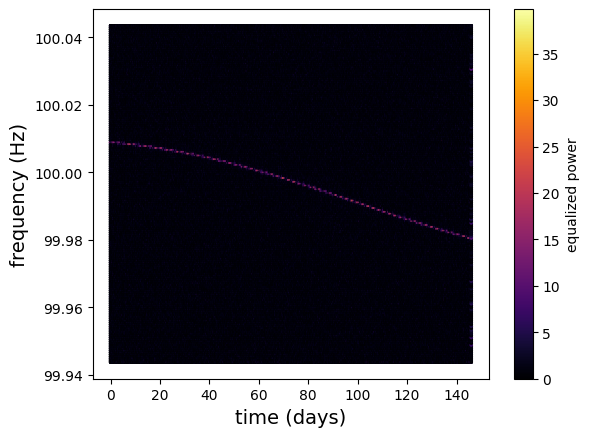

In [9]:
flat_times,flat_freqs,flat_pows = pyhough.pm.flatten_spectrogram(times["H1"],freqs,normalized_power)
pyhough.pm.python_plot_triplets((flat_times-flat_times[0])/86400,flat_freqs,flat_pows,'.',label='equalized power')
plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);

# Create peakmap from spectrogram

Here, we take the spectrogram computed in PyFstat, and, in each Fast Fourier Transform (that is, at each time in the spectrogram), select local maxima above a chosen threshold. The local maxima criteria reduce the impact of noise lines that may pollute multiple adjacent frequency bins.

We call the resulting thresholded spectrogram a "peakmap", where each surviving time/frequency pixel is called a "peak".

#### Setting threshold on peak selection to be:

In [10]:
threshold = 3 # need to apply a threshold on equalized power and select maxima above this threshold to run Hough
pm_times,pm_freqs,pm_pows,index = pyhough.pm.make_peakmap_from_spectrogram(times["H1"],freqs,normalized_power,threshold)

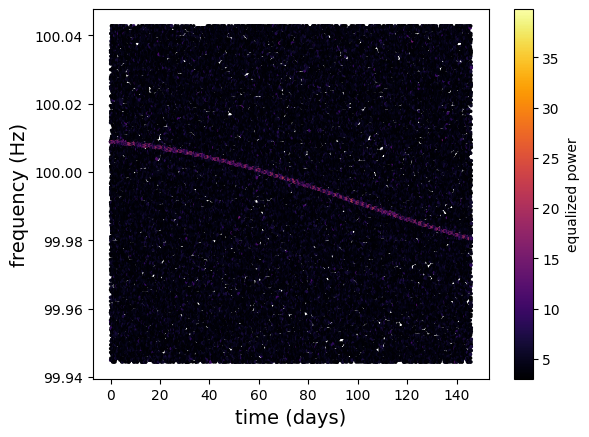

In [11]:
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,pm_freqs,pm_pows,'.',label='equalized power')
plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);
# plt.ylim([99.98,100.02])

# Create source position vector and get detector velocities for Dopp Corr

In [12]:
# source position and detector velocities
position = [signal_parameters["Alpha"], signal_parameters["Delta"]]
vec_n = pyhough.pm.astro2rect(position,1)
ts,vs = pyhough.pm.get_detector_velocities(data)
Nts = len(ts)

26-05-10 00:07:07.675 pyfstat.utils.ephemeris INFO    : No /root/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


INFO:pyfstat.utils.ephemeris:No /root/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


# Remove Doppler shift from peakmap

To search for a continuous wave coming from a particular sky location, we "point" our detector by correcting the data for the Doppler shift induced by the relative motion of earth and the source. In this method, the Doppler correction is a shifting of the time/frequency peaks in the peakmap for a given sky location.

Essentially, this corresponds to the following

\begin{equation}
\frac{f(t)}{\left(1+\frac{\vec{v}\cdot\hat{n}}{c}\right)} = f_0 +\dot{f}(t-t_0) \tag{2}
\end{equation}

Now, the new frequency is simply:

\begin{equation}
f_{\rm new}(t) = f_0 + \dot{f}(t-t_0)
\end{equation}

and we can apply the frequency-Hough Transform to search for this modulation.




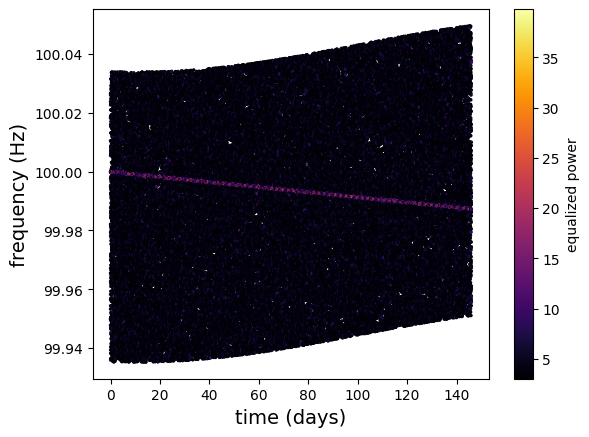

In [13]:
pm_freqs_undop = pyhough.pm.remove_doppler_from_peakmap(pm_times,pm_freqs,index,vec_n,vs,Nts) # Eq. 2
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,np.array(pm_freqs_undop),pm_pows,'.',label='equalized power')
# plt.ylim([99.989,100.002]);
plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);

# Analysis and relevant signal parameters

In [14]:
alltimes = times["H1"] ### the times of the analysis
Tsft = data_parameters["Tsft"] # the FFT length used
df = 1/Tsft # the frequency bin size
Tobs = data_parameters["duration"] # the duration of the peakmap in seconds
ref_perc_time = 0.5 * 100 # reference time for the Hough at which f0 is determined, set any number between 0 (beginning), 100 (end)
sig_fdot = signal_parameters['F1'] #spin-down of injected signal
dsd = 1/(Tsft*Tobs) # step in spin-down: dsd = df / Tobs
sdgrid = pyhough.hm.make_sd_grid(sig_fdot,dsd) ## grid of spin-downs to search over

# Run frequency-Hough on Doppler corrected peakmap and plot Hough map


The input is the time/frequency peakmap, which is simply a collection of ones. For given choices of $\dot{f}$, we solve for $f_0$

\begin{equation}
f_0 = f_{\rm new}-\dot{f}(t-t_0)
\end{equation}

We thus need to specify a range of $\dot{f}$ values with a particular spacing, given by:

\begin{equation}
\delta\dot{f} = df/T_{\rm obs}
\end{equation}
where $\delta f=1/T_{\rm FFT}$ and $T_{\rm FFT}$ is the FFT length (1800 s in this case), and specify a maximum and minimum $\dot{f}$ to search over.

The Hough sums ones along the time/frequency tracks of the signals, NOT the equalized power on the color axis that is seen in the peakmap plots

The output of this code $\texttt{hmap\_from\_pm}$ is a 2-dimensional histogram in the $f_0$/$\dot{f}$ plane of the source.

In [15]:
hmap_from_pm = pyhough.hm.hfdf_hough(pm_times,pm_freqs_undop,Tsft,sdgrid,ref_perc_time)
fs_for_hmap_from_pm = np.arange(np.min(pm_freqs_undop),np.max(pm_freqs_undop),df)

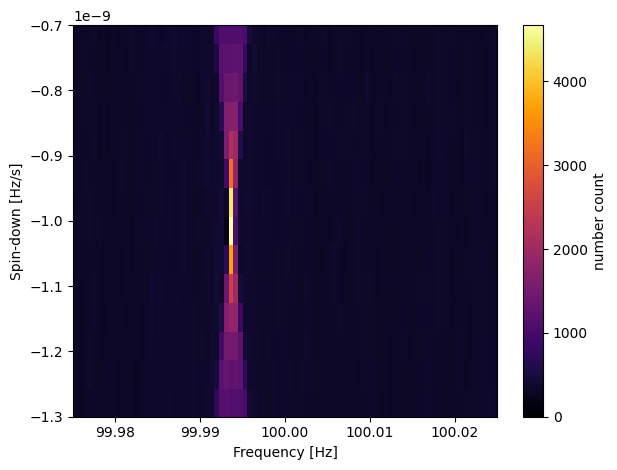

In [16]:
fig, ax = plt.subplots()#figsize=(0.8 * 16, 0.8 * 9))
ax.set(ylabel="Spin-down [Hz/s]", xlabel=r"Frequency [Hz]")#, ylim=(99.98, 100.02))
c = ax.pcolormesh(
    fs_for_hmap_from_pm,
    sdgrid,
    hmap_from_pm,
    cmap="inferno",
    shading="nearest",
)
fig.colorbar(c, label="number count")
plt.tight_layout()
ax.set(ylim=(sig_fdot*1.3,-0.7e-9));
ax.set(xlim=(99.975,100.025));
# plt.savefig('hm_map.jpg',format='png',dpi=400)

### Q1:
Why are there seemingly negative slopes of the lines in this map? Can you guess which parameter you need to change to obtain all positive slopes or a mix of positive and negative sloped lines?

The apparent negative slopes are due to the way the spin-down axis is displayed. In the plot, the y-axis limits are set as

`ax.set(ylim=(sig_fdot*1.3, -0.7e-9))`

which reverses the vertical axis. As a result, tracks that would normally appear with positive slope are shown with negative slope.

To display all slopes in the usual orientation, the y-axis limits should be reversed:

`ax.set(ylim=(-0.7e-9, sig_fdot*1.3))`

If the spin-down grid `sdgrid` includes both positive and negative values of $\dot{f}$, then the Hough map will contain a mixture of positive and negative slopes.

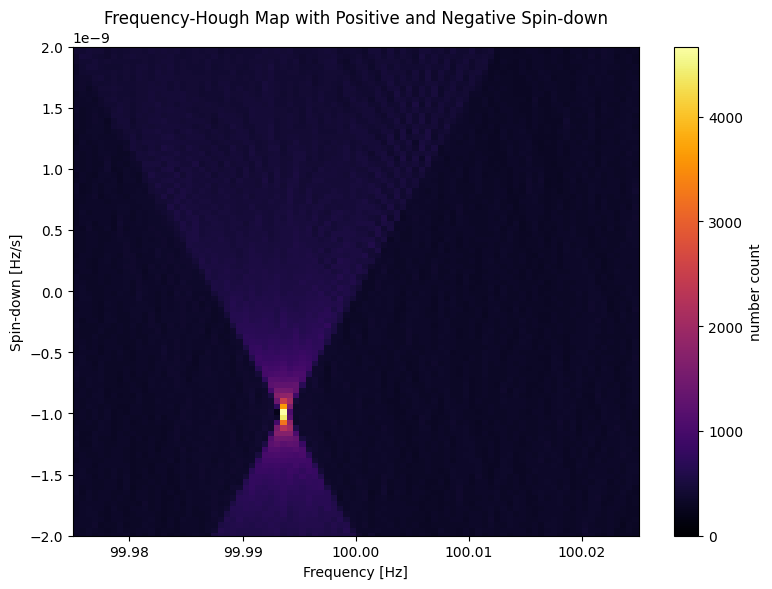

In [17]:
# Create a spin-down grid that includes both negative and positive values
# so the Hough map shows a mixture of slope directions.

sd_min = -2.0e-9   # minimum spin-down
sd_max =  2.0e-9   # maximum spin-down
sd_step = df / Tobs   # required spacing: δf_dot = df / Tobs

sdgrid = np.arange(sd_min, sd_max + sd_step, sd_step)

# Recompute the Hough map with the new spin-down grid
hmap_from_pm = pyhough.hm.hfdf_hough(
    pm_times,
    pm_freqs_undop,
    Tsft,
    sdgrid,
    ref_perc_time
)

fs_for_hmap_from_pm = np.arange(
    np.min(pm_freqs_undop),
    np.max(pm_freqs_undop),
    df
)

# Plot the updated Hough map
fig, ax = plt.subplots(figsize=(8, 6))
ax.set(
    xlabel="Frequency [Hz]",
    ylabel="Spin-down [Hz/s]",
    title="Frequency-Hough Map with Positive and Negative Spin-down"
)

c = ax.pcolormesh(
    fs_for_hmap_from_pm,
    sdgrid,
    hmap_from_pm,
    cmap="inferno",
    shading="nearest",
)

fig.colorbar(c, label="number count")

# Show the full spin-down range
ax.set_xlim(99.975, 100.025)
ax.set_ylim(sd_min, sd_max)

plt.tight_layout()
plt.show()

### Q2:
If the true signal frequency and spin-down are F0 and F1, respectively, why are there multiple pixels in this map surrounding the true values?

The Hough map is computed on a discrete grid in frequency and spin-down, with resolutions: $$\delta f = \frac{1}{T_{\mathrm{FFT}}} \qquad \delta \dot{f} = \frac{\delta f}{T_{\mathrm{obs}}}$$

The true signal parameters $(F_0, F_1)$ will generally not lie exactly at the center of a single grid cell. Consequently, the signal contributes to several neighboring pixels.

The spread is also caused by:

- finite frequency and spin-down resolution,
- noise fluctuations,
- thresholding in the peakmap construction,
- small mismatches between the true signal track and the discrete search grid.

Therefore, the signal appears as a cluster of bright pixels around the true values rather than as a single isolated pixel.

# Apply wrong Doppler correction to peakmap, run Hough, and plot

In [18]:
wrong_position = [np.pi/4, np.pi/5]
wrong_vec_n = pyhough.pm.astro2rect(wrong_position,1)

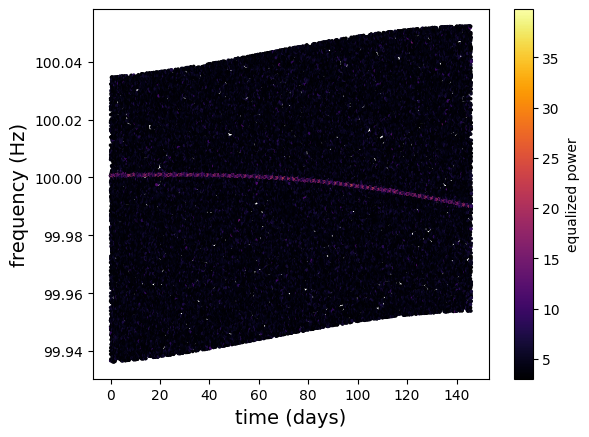

In [19]:
pm_freqs_undop_wrong = pyhough.pm.remove_doppler_from_peakmap(pm_times,pm_freqs,index,wrong_vec_n,vs,Nts)
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,np.array(pm_freqs_undop_wrong),pm_pows,'.',label='equalized power')
# plt.ylim([99.989,100.002]);
plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);

### Q3:
Do you see the difference between using the wrong and correct source positions to correct the peakmap? What can you conclude about the ability of this method to localize sources in the sky?



Yes. When the correct sky position is used, the Doppler modulation is properly removed and the signal becomes nearly monochromatic, appearing as a horizontal track in the peakmap.

When an incorrect sky position is used, the Doppler correction is inaccurate and residual frequency modulation remains. As a result, the signal track is still curved rather than perfectly horizontal.

This shows that the method is sensitive to the source sky position. The Hough transform produces the strongest and most concentrated peak only when the correct sky position is used, which means that by searching over many sky positions, the source can be localized on the sky.


### Q4:
What do you think will happen to a monochromatic noise line after the Doppler correction is applied? Is this good or not? Why?

A monochromatic instrumental noise line has a constant detector-frame frequency.

After Doppler correction, the frequency is shifted according to the assumed sky position and detector motion. Since the noise line does not originate from a fixed astrophysical source, this correction introduces an artificial modulation, causing the line to spread over multiple frequency bins instead of remaining at a single frequency.

This is beneficial because the line becomes less coherent and its power is distributed over many bins, reducing its significance in the Hough map. In contrast, a true astrophysical signal becomes more coherent after the correct Doppler correction and therefore stands out more clearly.


In [20]:
#### run Hough
hmap_wrong_pos = pyhough.hm.hfdf_hough(pm_times,pm_freqs_undop_wrong,Tsft,sdgrid,ref_perc_time)
fs_for_hmap_from_spec_wrong_position = np.arange(np.min(pm_freqs_undop_wrong),np.max(pm_freqs_undop_wrong),df)

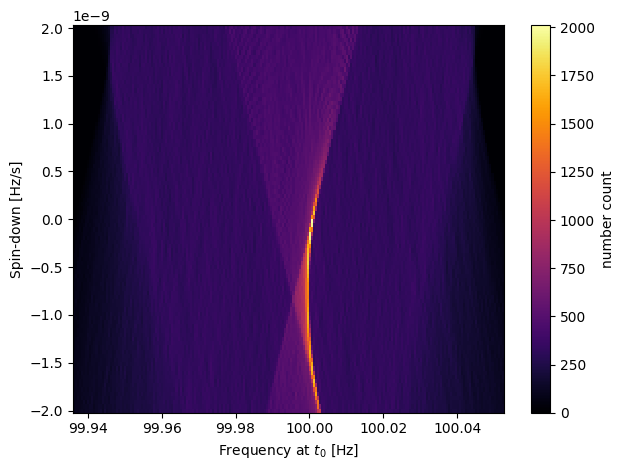

In [21]:
fig, ax = plt.subplots()#figsize=(0.8 * 16, 0.8 * 9))
ax.set(ylabel="Spin-down [Hz/s]", xlabel=r"Frequency at $t_0$ [Hz]")#, ylim=(99.98, 100.02))
c = ax.pcolormesh(
    fs_for_hmap_from_spec_wrong_position,
    sdgrid,
    hmap_wrong_pos,
    cmap="inferno",
    shading="nearest",
)
fig.colorbar(c, label="number count")
plt.tight_layout()
# ax.set(ylim=(sig_fdot*2,-sig_fdot*1.1));

### Q5:
Compare the peak number count at the source frequency and spin-down in this Hough map and the one run on the properly corrected peakmap. Why is there a reduction in the number count?



When the correct sky position is used, the Doppler modulation is removed accurately and the signal peaks from different times align coherently in the Hough transform. This produces a sharp peak with a high number count.

When the wrong sky position is used, the Doppler correction is imperfect, so the signal does not align exactly. The peaks are spread over multiple neighboring pixels, reducing the number of peaks accumulated in any single bin.

Therefore, the Hough map generated with the wrong sky position has a lower and broader peak compared to the properly corrected Hough map.

In [23]:
idx_correct = np.unravel_index(np.argmax(hmap_from_pm), hmap_from_pm.shape)
idx_wrong = np.unravel_index(np.argmax(hmap_wrong_pos), hmap_wrong_pos.shape)

print(f"Maximum count (correct sky position): {hmap_from_pm[idx_correct]}")
print(f"Maximum count (wrong sky position): {hmap_wrong_pos[idx_wrong]}")

Maximum count (correct sky position): 4670.0
Maximum count (wrong sky position): 2011.0
